In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ---- CELLULE 1 : Installation ----
!pip install ultralytics roboflow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 78.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.0/285.0 kB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 83.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 120.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 5.7 MB/s eta 0:00:00


In [3]:
# ---- CELLULE 2 : Import du dataset depuis Roboflow ----
from roboflow import Roboflow

rf = Roboflow(api_key="MGyf2MlIeUCGXuVuj0Gj")
project = rf.workspace("airborne-object-detection").project("airborne-object-detection-4-aod4")
version = project.version(4)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Airborne-Object-Detection-4-AOD4-4 in yolov8:: 100%|██████████| 42690/42690 [00:08<00:00, 4748.85it/s] 


Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
# ---- CELLULE 3 : Vérification du dataset ----
import os
print("Dataset path:", dataset.location)
print("Contenu:", os.listdir(dataset.location))

# Vérifier le fichier data.yaml
yaml_path = os.path.join(dataset.location, "data.yaml")
with open(yaml_path, "r") as f:
    print("\ndata.yaml:")
    print(f.read())

Dataset path: /content/Airborne-Object-Detection-4-AOD4-4
Contenu: ['README.dataset.txt', 'train', 'valid', 'data.yaml', 'README.roboflow.txt', 'test']

data.yaml:
names:
- airplane
- bird
- drone
- helicopter
nc: 4
roboflow:
  license: CC BY 4.0
  project: air-borne-objects
  url: https://universe.roboflow.com/scaai-research-internship/air-borne-objects/dataset/4
  version: 4
  workspace: scaai-research-internship
test: ../test/images
train: ../train/images
val: ../valid/images



In [ ]:
# ---- CELLULE 4 : Fine-tuning YOLOv8n ----
from ultralytics import YOLO

# Charger le modèle YOLOv8n pré-entraîné
model = YOLO("yolov8n.pt")

# Lancer le fine-tuning
results = model.train(
    data=yaml_path,
    epochs=30,
    imgsz=640,
    batch=16,
    name="aod4_yolov8n",
    project="/content/drive/MyDrive/AOD4",
    patience=10,
    save=True,
    device=0  # GPU
)

Ultralytics 8.4.100 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Airborne-Object-Detection-4-AOD4-4/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=aod4_yolov8n, nbs=64, nms=False, opset=None, optimize=False

In [ ]:
# ---- CELLULE 5 : Évaluation sur le set de validation ----
from ultralytics import YOLO

# Charger le meilleur modèle
best_model = YOLO("/content/drive/MyDrive/AOD4/aod4_yolov8n/weights/best.pt")

# Évaluation
metrics = best_model.val(data=yaml_path)

print("\n=== RÉSULTATS ===")
print(f"mAP50   : {metrics.box.map50:.3f}")
print(f"mAP50-95: {metrics.box.map:.3f}")
print(f"Precision: {metrics.box.mp:.3f}")
print(f"Recall  : {metrics.box.mr:.3f}")

Ultralytics 8.4.116 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 717.4±235.7 MB/s, size: 17.9 KB)
val: Scanning /content/Airborne-Object-Detection-4-AOD4-4/valid/labels... 4276 images, 111 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4276/4276 2.0Kit/s 2.1s
val: New cache created: /content/Airborne-Object-Detection-4-AOD4-4/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 268/268 5.9it/s 45.0s
                   all       4276       6059      0.945      0.929      0.962       0.64
              airplane       1023       1529       0.95      0.919      0.958      0.673
                  bird        625       1487      0.936      0.947       0.97      0.682
                 drone       1427       1536      0.947      0.913      0.955      0.603
            helicopter 

Image testée: /content/Airborne-Object-Detection-4-AOD4-4/valid/images/V_DRONE_092202_195_png_jpg.rf.3f2b32d007de3f4b30ccf9fe2cd83184.jpg

image 1/1 /content/Airborne-Object-Detection-4-AOD4-4/valid/images/V_DRONE_092202_195_png_jpg.rf.3f2b32d007de3f4b30ccf9fe2cd83184.jpg: 640x640 1 drone, 12.0ms
Speed: 3.9ms preprocess, 12.0ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


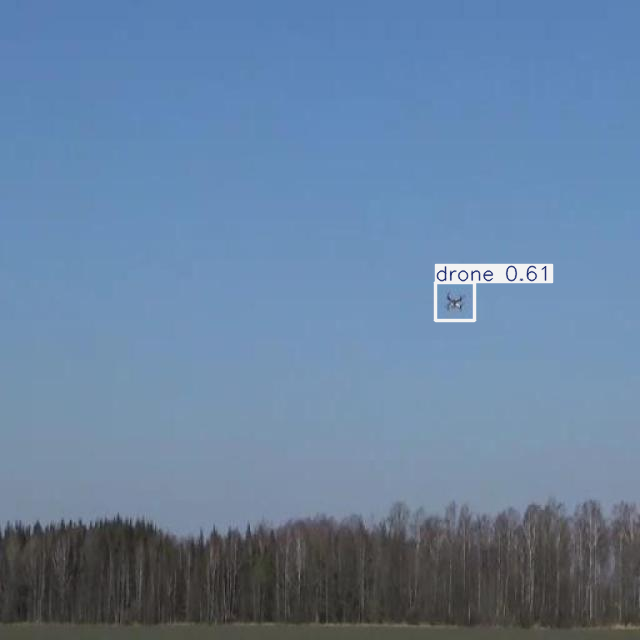

In [ ]:
# ---- CELLULE 6 : Test sur une image ----
import glob
import random

# Prendre une image aléatoire du set de validation
val_images = glob.glob(os.path.join(dataset.location, "valid/images/*.jpg"))
test_img = random.choice(val_images)
print("Image testée:", test_img)

# Prédiction
results = best_model.predict(test_img, conf=0.25, save=True)
results[0].show()

In [5]:
!pip install albumentations -q
import cv2
import numpy as np
import albumentations as A
print("Librairies OK ✅")

Librairies OK ✅


In [6]:
import shutil
from pathlib import Path

def apply_haze(image, t):
    """Haze: I_haze = I * t + 255 * (1 - t)"""
    image = image.astype(np.float32)
    hazy = image * t + 255 * (1 - t)
    return np.clip(hazy, 0, 255).astype(np.uint8)

def apply_blur(image, sigma):
    """Gaussian Blur"""
    kernel_size = int(6 * sigma + 1)
    if kernel_size % 2 == 0:
        kernel_size += 1
    return cv2.GaussianBlur(image, (kernel_size, kernel_size), sigma)

def apply_noise(image, sigma):
    """Gaussian Noise: I + N(0, sigma²)"""
    noise = np.random.normal(0, sigma, image.shape)
    noisy = image.astype(np.float32) + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)

def apply_rain(image, params):
    """Rain streaks using albumentations"""
    rain_type, drop_length, drop_width, brightness = params
    transform = A.RandomRain(
        drop_length=drop_length,
        drop_width=drop_width,
        drop_color=(200, 200, 200),
        blur_value=3,
        brightness_coefficient=brightness,
        rain_type=rain_type,
        p=1.0
    )
    return transform(image=image)['image']

def apply_lowlight(image, gamma):
    """Low-light: I_dark = (I/255)^gamma * 255"""
    image = image.astype(np.float32) / 255.0
    dark = np.power(image, gamma) * 255.0
    return np.clip(dark, 0, 255).astype(np.uint8)

def apply_jpeg(image, quality):
    """JPEG compression"""
    encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), quality]
    _, encoded = cv2.imencode('.jpg', image, encode_param)
    return cv2.imdecode(encoded, cv2.IMREAD_COLOR)

# Dictionnaire de toutes les corruptions et leurs paramètres
CORRUPTIONS = {
    "haze":     {"func": apply_haze,     "params": [("mild", 0.7), ("moderate", 0.5), ("severe", 0.3)]},
    "blur":     {"func": apply_blur,     "params": [("mild", 1.0), ("moderate", 2.0), ("severe", 3.0)]},
    "noise":    {"func": apply_noise,    "params": [("mild", 10),  ("moderate", 25),  ("severe", 50)]},
    "rain": {
    "func": apply_rain,
    "params": [
        ("mild",     ('drizzle',    10, 1, 0.95)),
        ("moderate", ('heavy',      20, 2, 0.85)),
        ("severe",   ('torrential', 30, 3, 0.70)),
    ]
},
    "lowlight": {"func": apply_lowlight, "params": [("mild", 1.5), ("moderate", 2.5), ("severe", 4.0)]},
    "jpeg":     {"func": apply_jpeg,     "params": [("mild", 60),  ("moderate", 30),  ("severe", 10)]},
}

print("Fonctions de corruption définies ✅")

Fonctions de corruption définies ✅


In [ ]:
import shutil
from pathlib import Path

val_img_dir = Path(dataset.location) / "valid" / "images"
val_lbl_dir = Path(dataset.location) / "valid" / "labels"
output_base = Path("/content/drive/MyDrive/AOD4/corrupted")

print(f"Images de validation : {len(list(val_img_dir.glob('*.jpg')))}")

for corruption_name, corruption_info in CORRUPTIONS.items():

    func = corruption_info["func"]
    for severity_name, param in corruption_info["params"]:
        # Créer le dossier de sortie
        out_img_dir = output_base / f"{corruption_name}_{severity_name}" / "images"
        out_lbl_dir = output_base / f"{corruption_name}_{severity_name}" / "labels"
        out_img_dir.mkdir(parents=True, exist_ok=True)
        out_lbl_dir.mkdir(parents=True, exist_ok=True)

        print(f"Génération : {corruption_name}_{severity_name}...", end=" ")

        for img_path in val_img_dir.glob("*.jpg"):
            # Lire l'image
            img = cv2.imread(str(img_path))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Appliquer la corruption
            if corruption_name == "rain":
                corrupted = func(img, param)
            else:
                corrupted = func(img, param)

            # Sauvegarder l'image corrompue
            corrupted_bgr = cv2.cvtColor(corrupted, cv2.COLOR_RGB2BGR)
            cv2.imwrite(str(out_img_dir / img_path.name), corrupted_bgr)

            # Copier le fichier label (annotations inchangées)
            lbl_path = val_lbl_dir / (img_path.stem + ".txt")
            if lbl_path.exists():
                shutil.copy(str(lbl_path), str(out_lbl_dir / lbl_path.name))

        print("✅")

print("\nToutes les corruptions générées ✅")

Images de validation : 4276
Génération : haze_mild... 

KeyboardInterrupt: 

In [ ]:
# ============================================================
# RÉGÉNÉRER UNIQUEMENT RAIN
# ============================================================

import shutil
from pathlib import Path

val_img_dir = Path(dataset.location) / "valid" / "images"
val_lbl_dir = Path(dataset.location) / "valid" / "labels"
output_base = Path("/content/drive/MyDrive/AOD4/corrupted")

corruption_name = "rain"
corruption_info = CORRUPTIONS[corruption_name]
func = corruption_info["func"]

print(f"Images de validation : {len(list(val_img_dir.glob('*.jpg')))}")

for severity_name, param in corruption_info["params"]:

    out_img_dir = output_base / f"{corruption_name}_{severity_name}" / "images"
    out_lbl_dir = output_base / f"{corruption_name}_{severity_name}" / "labels"

    out_img_dir.mkdir(parents=True, exist_ok=True)
    out_lbl_dir.mkdir(parents=True, exist_ok=True)

    print(f"Génération : rain_{severity_name}...", end=" ")

    for img_path in val_img_dir.glob("*.jpg"):

        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Nouvelle fonction Rain
        corrupted = func(img, param)

        corrupted_bgr = cv2.cvtColor(corrupted, cv2.COLOR_RGB2BGR)

        cv2.imwrite(
            str(out_img_dir / img_path.name),
            corrupted_bgr
        )

        # Copier le label
        lbl_path = val_lbl_dir / (img_path.stem + ".txt")

        if lbl_path.exists():
            shutil.copy(
                str(lbl_path),
                str(out_lbl_dir / lbl_path.name)
            )

    print("✅")

print("\nRain uniquement régénéré ✅")

Images de validation : 4276
Génération : rain_mild... ✅
Génération : rain_moderate... ✅
Génération : rain_severe... ✅

Rain uniquement régénéré ✅


In [ ]:
import pandas as pd

# Classes AOD-4
CLASSES = ["airplane", "bird", "drone", "helicopter"]

# Baseline (résultats sur images propres)
baseline_map50 = 0.962

results = []

for corruption_name, corruption_info in CORRUPTIONS.items():

    for severity_name, param in corruption_info["params"]:

        folder = output_base / f"{corruption_name}_{severity_name}"

        # Créer data.yaml temporaire pour ce dossier corrompu
        yaml_content = f"""
path: {folder}
train: images
val: images
nc: 4
names: ['airplane', 'bird', 'drone', 'helicopter']
"""
        yaml_tmp = folder / "data.yaml"
        with open(str(yaml_tmp), "w") as f:
            f.write(yaml_content)

        print(f"Évaluation : {corruption_name}_{severity_name}...", end=" ")

        # Évaluer
        metrics = best_model.val(
            data=str(yaml_tmp),
            verbose=False,
            plots=False
        )

        map50 = metrics.box.map50
        map50_95 = metrics.box.map
        per_class = metrics.box.maps  # mAP50-95 par classe

        # Calculer la chute relative
        drop = (baseline_map50 - map50) / baseline_map50 * 100

        results.append({
            "corruption": corruption_name,
            "severity": severity_name,
            "mAP50": round(map50, 3),
            "mAP50-95": round(map50_95, 3),
            "drop_%": round(drop, 1),
        })

        print(f"mAP50={map50:.3f} (chute: {drop:.1f}%)")

# Créer le tableau final
df = pd.DataFrame(results)
print("\n=== TABLEAU DE ROBUSTESSE ===")
print(df.to_string(index=False))

# Sauvegarder
df.to_csv("/content/drive/MyDrive/AOD4/robustness_results.csv", index=False)
print("\nRésultats sauvegardés ✅")

Évaluation : haze_mild... Ultralytics 8.4.107 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.6±0.1 ms, read: 0.1±0.0 MB/s, size: 26.4 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/drive/MyDrive/AOD4/corrupted/haze_mild/labels... 4276 images, 111 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4276/4276 3.4it/s 20:44
val: New cache created: /content/drive/MyDrive/AOD4/corrupted/haze_mild/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 268/268 6.3it/s 42.4s
                   all       4276       6059      0.946      0.915      0.956      0.634
Speed: 1.3ms preprocess, 3.6ms inference, 0.0ms loss, 1.6ms postprocess per image
mAP50=0.956 (chute: 0.6%)
Évaluati

In [ ]:
baseline_map50 = 0.962

In [ ]:
# ============================================================
# ÉVALUER UNIQUEMENT RAIN
# ============================================================

import pandas as pd

corruption_name = "rain"
corruption_info = CORRUPTIONS[corruption_name]

rain_results = []

for severity_name, param in corruption_info["params"]:

    folder = output_base / f"{corruption_name}_{severity_name}"

    # data.yaml
    yaml_content = f"""
path: {folder}
train: images
val: images
nc: 4
names: ['airplane', 'bird', 'drone', 'helicopter']
"""

    yaml_tmp = folder / "data.yaml"

    with open(str(yaml_tmp), "w") as f:
        f.write(yaml_content)

    print(f"Évaluation : rain_{severity_name}...", end=" ")

    # Évaluation
    metrics = best_model.val(
        data=str(yaml_tmp),
        verbose=False,
        plots=False
    )

    map50 = metrics.box.map50
    map50_95 = metrics.box.map

    # Chute par rapport au baseline
    drop = (baseline_map50 - map50) / baseline_map50 * 100

    rain_results.append({
        "corruption": "rain",
        "severity": severity_name,
        "mAP50": round(map50, 3),
        "mAP50-95": round(map50_95, 3),
        "drop_%": round(drop, 1),
    })

    print(
        f"mAP50={map50:.3f} "
        f"(chute: {drop:.1f}%)"
    )

# Tableau Rain
df_rain = pd.DataFrame(rain_results)

print("\n=== RÉSULTATS RAIN ===")
print(df_rain.to_string(index=False))

# Sauvegarder
df_rain.to_csv(
    "/content/drive/MyDrive/AOD4/rain_robustness_results.csv",
    index=False
)

print("\nRésultats Rain sauvegardés ✅")

Évaluation : rain_mild... Ultralytics 8.4.116 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
WARNING ⚠️ val: Slow image access detected (ping: 5.8±11.5 ms, read: 41.0±21.3 MB/s, size: 49.1 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/drive/MyDrive/AOD4/corrupted/rain_mild/labels.cache... 4276 images, 111 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4276/4276 815.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 268/268 6.1it/s 44.0s
                   all       4276       6059       0.87      0.516      0.686      0.416
Speed: 1.2ms preprocess, 3.6ms inference, 0.0ms loss, 1.7ms postprocess per image
mAP50=0.686 (chute: 28.7%)
Évaluation : rain_moderate... Ultralytics 8.4.116 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.4±0.0 ms, rea

In [ ]:
from ultralytics import YOLO
import numpy as np
import cv2
from pathlib import Path
import shutil
import random

random.seed(42)

train_img_dir = Path(dataset.location) / "train" / "images"
train_lbl_dir = Path(dataset.location) / "train" / "labels"
val_dir = Path(dataset.location) / "valid"

# ── Étape 1 : Prendre seulement 3000 images aléatoires ──
all_imgs = list(train_img_dir.glob("*.jpg"))
subset_imgs = random.sample(all_imgs, 3000)

augmented_dir = Path("/content/aod4_noise_robust")
aug_img_dir = augmented_dir / "images"
aug_lbl_dir = augmented_dir / "labels"
aug_img_dir.mkdir(parents=True, exist_ok=True)
aug_lbl_dir.mkdir(parents=True, exist_ok=True)

noise_sigmas = [10, 25, 50]

for img_path in subset_imgs:
    img = cv2.imread(str(img_path))
    lbl_path = train_lbl_dir / (img_path.stem + ".txt")

    # Image originale
    shutil.copy(str(img_path), str(aug_img_dir / img_path.name))
    if lbl_path.exists():
        shutil.copy(str(lbl_path), str(aug_lbl_dir / lbl_path.name))

    # Version bruitée
    sigma = random.choice(noise_sigmas)
    noise = np.random.normal(0, sigma, img.shape)
    noisy = np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)
    cv2.imwrite(str(aug_img_dir / f"noise_{img_path.name}"), noisy)
    if lbl_path.exists():
        shutil.copy(str(lbl_path), str(aug_lbl_dir / f"noise_{lbl_path.name}"))

print(f"Dataset créé : {len(list(aug_img_dir.glob('*.jpg')))} images ✅")

# ── Étape 2 : data.yaml ──
yaml_content = f"""path: /content/aod4_noise_robust
train: images
val: {val_dir}
nc: 4
names: ['airplane', 'bird', 'drone', 'helicopter']
"""
yaml_aug = augmented_dir / "data.yaml"
with open(str(yaml_aug), "w") as f:
    f.write(yaml_content)
print("data.yaml créé ✅")

# ── Étape 3 : Fine-tuning ──
model_robust = YOLO("/content/drive/MyDrive/AOD4/aod4_yolov8n/weights/best.pt")

model_robust.train(
    data=str(yaml_aug),
    epochs=10,
    imgsz=640,
    batch=16,
    name="aod4_robust_noise",
    project="/content/drive/MyDrive/AOD4",
    patience=5,
    lr0=0.001,
    dropout=0.1,
    save=True,
    device=0,
    seed=42
)

print("Fine-tuning terminé ✅")

Dataset créé : 6000 images ✅
data.yaml créé ✅
Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/aod4_noise_robust/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.1, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/AOD4/aod4_yolov8

In [ ]:
import pandas as pd
import random
import shutil
import cv2
import numpy as np
from pathlib import Path
from ultralytics import YOLO
import albumentations as A

random.seed(42)

CLASSES = ["airplane", "bird", "drone", "helicopter"]
baseline_map50 = 0.962
baseline_per_class = {
    "airplane": 0.958,
    "bird": 0.970,
    "drone": 0.955,
    "helicopter": 0.965
}

# Charger le modèle
model_robust = YOLO("/content/drive/MyDrive/AOD4/aod4_robust_noise/weights/best.pt")

val_img_dir = Path(dataset.location) / "valid" / "images"
val_lbl_dir = Path(dataset.location) / "valid" / "labels"

# Subset val fixe (500 images, seed=42)
all_val = list(val_img_dir.glob("*.jpg"))
subset_val = random.sample(all_val, 500)

# Fonctions de corruption
def apply_haze(image, t):
    image = image.astype(np.float32)
    return np.clip(image * t + 255 * (1 - t), 0, 255).astype(np.uint8)

def apply_blur(image, sigma):
    k = int(6 * sigma + 1)
    if k % 2 == 0: k += 1
    return cv2.GaussianBlur(image, (k, k), sigma)

def apply_noise(image, sigma):
    noise = np.random.normal(0, sigma, image.shape)
    return np.clip(image.astype(np.float32) + noise, 0, 255).astype(np.uint8)

def apply_rain(image, params):
    rain_type, drop_length, drop_width, brightness = params
    transform = A.RandomRain(
        drop_length=drop_length,
        drop_width=drop_width,
        drop_color=(200, 200, 200),
        blur_value=3,
        brightness_coefficient=brightness,
        rain_type=rain_type,
        p=1.0
    )
    img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    result = transform(image=img_rgb)['image']
    return cv2.cvtColor(result, cv2.COLOR_RGB2BGR)

def apply_lowlight(image, gamma):
    image = image.astype(np.float32) / 255.0
    return np.clip(np.power(image, gamma) * 255.0, 0, 255).astype(np.uint8)

def apply_jpeg(image, quality):
    encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), quality]
    _, encoded = cv2.imencode('.jpg', image, encode_param)
    return cv2.imdecode(encoded, cv2.IMREAD_COLOR)

# Toutes les corruptions
CORRUPTIONS = {
    "haze":     [("mild", 0.7), ("moderate", 0.5), ("severe", 0.3)],
    "blur":     [("mild", 1.0), ("moderate", 2.0), ("severe", 3.0)],
    "noise":    [("mild", 10),  ("moderate", 25),  ("severe", 50)],
    "rain":     [("mild", ('drizzle', 10, 1, 0.95)), ("moderate", ('heavy', 20, 2, 0.85)), ("severe", ('torrential', 30, 3, 0.70))],
    "lowlight": [("mild", 1.5), ("moderate", 2.5), ("severe", 4.0)],
    "jpeg":     [("mild", 60),  ("moderate", 30),  ("severe", 10)],
}

FUNCS = {
    "haze": apply_haze,
    "blur": apply_blur,
    "noise": apply_noise,
    "rain": apply_rain,
    "lowlight": apply_lowlight,
    "jpeg": apply_jpeg,
}

results = []

for corruption_name, levels in CORRUPTIONS.items():
    for severity_name, param in levels:

        # Créer dossier corrompu
        corrupt_dir = Path(f"/content/eval_{corruption_name}_{severity_name}")
        corrupt_img = corrupt_dir / "images"
        corrupt_lbl = corrupt_dir / "labels"
        corrupt_img.mkdir(parents=True, exist_ok=True)
        corrupt_lbl.mkdir(parents=True, exist_ok=True)

        # Générer images corrompues
        for img_path in subset_val:
            img = cv2.imread(str(img_path))
            corrupted = FUNCS[corruption_name](img, param)
            cv2.imwrite(str(corrupt_img / img_path.name), corrupted)
            lbl_path = val_lbl_dir / (img_path.stem + ".txt")
            if lbl_path.exists():
                shutil.copy(str(lbl_path), str(corrupt_lbl / lbl_path.name))

        # data.yaml
        yaml_content = f"""path: {corrupt_dir}
train: images
val: images
nc: 4
names: ['airplane', 'bird', 'drone', 'helicopter']
"""
        yaml_tmp = corrupt_dir / "data.yaml"
        with open(str(yaml_tmp), "w") as f:
            f.write(yaml_content)

        # Évaluation
        metrics = model_robust.val(
            data=str(yaml_tmp),
            verbose=False,
            plots=False,
            workers=0
        )

        # Overall
        map50_overall = metrics.box.map50
        drop_overall = (baseline_map50 - map50_overall) / baseline_map50 * 100

        results.append({
            "corruption": corruption_name,
            "severity": severity_name,
            "class": "ALL",
            "mAP50_baseline": baseline_map50,
            "mAP50_corrupted": round(map50_overall, 3),
            "drop_%": round(drop_overall, 1)
        })

        # Par classe
        class_maps = metrics.box.ap50
        for i, cls_name in enumerate(CLASSES):
            if i < len(class_maps):
                cls_map50 = class_maps[i]
                cls_drop = (baseline_per_class[cls_name] - cls_map50) / baseline_per_class[cls_name] * 100
                results.append({
                    "corruption": corruption_name,
                    "severity": severity_name,
                    "class": cls_name,
                    "mAP50_baseline": baseline_per_class[cls_name],
                    "mAP50_corrupted": round(cls_map50, 3),
                    "drop_%": round(cls_drop, 1)
                })

        print(f"{corruption_name}_{severity_name} ✅ — overall mAP50={map50_overall:.3f} (chute: {drop_overall:.1f}%)")

# Tableau final
df = pd.DataFrame(results)
print("\n=== RÉSULTATS COMPLETS PAR CLASSE ===")
print(df.to_string(index=False))
df.to_csv("/content/drive/MyDrive/AOD4/results_all_corruptions_per_class.csv", index=False)
print("\nSauvegardé ✅")

Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1164.8±620.8 MB/s, size: 40.6 KB)
val: Scanning /content/eval_haze_mild/labels... 500 images, 19 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 500/500 2.1Kit/s 0.2s
val: New cache created: /content/eval_haze_mild/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 7.0it/s 4.6s
                   all        500        722      0.915      0.863      0.915      0.566
Speed: 0.4ms preprocess, 3.8ms inference, 0.0ms loss, 0.6ms postprocess per image
haze_mild ✅ — overall mAP50=0.915 (chute: 4.9%)
Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 884.0±351.2 MB/s, size: 30.2 KB)
val: Scanning /content/eval_haze_moderate/labels...


Recherche : noise_severe
📁 Dossier trouvé : /content/drive/MyDrive/AOD4/corrupted/noise_severe
✅ Failure trouvée : 20190926_193515_1_1_994_jpg.rf.837abb13ab6dff86f30f52e4128057f6.jpg


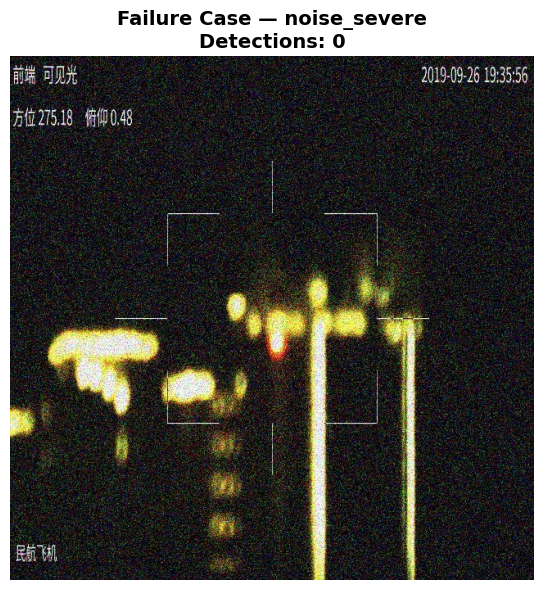

💾 Sauvegardé : /content/drive/MyDrive/AOD4/failure_noise_severe.png

Recherche : rain_moderate
📁 Dossier trouvé : /content/drive/MyDrive/AOD4/corrupted/rain_moderate
✅ Failure trouvée : yt-eKSZtbSEmwg-0206_jpg.rf.1abbba07b651bd9b1d493bc513105570.jpg


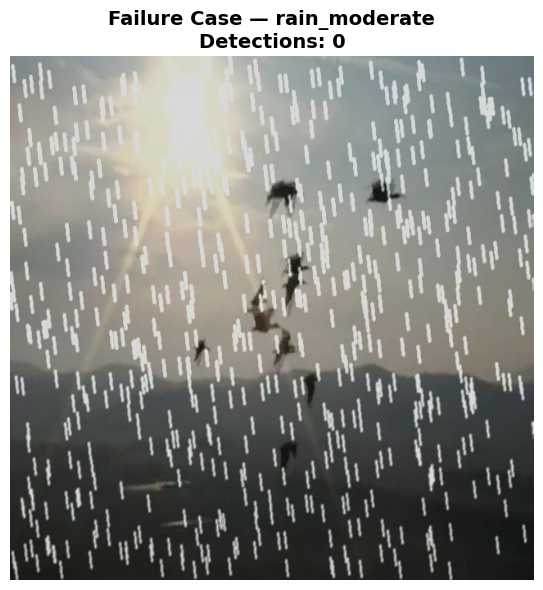

💾 Sauvegardé : /content/drive/MyDrive/AOD4/failure_rain_moderate.png

Recherche : rain_severe
📁 Dossier trouvé : /content/drive/MyDrive/AOD4/corrupted/rain_severe
✅ Failure trouvée : yt-sdq-6gAdNtE-0079_jpg.rf.b76a785dd943019f5a8f6bf1da51d54f.jpg


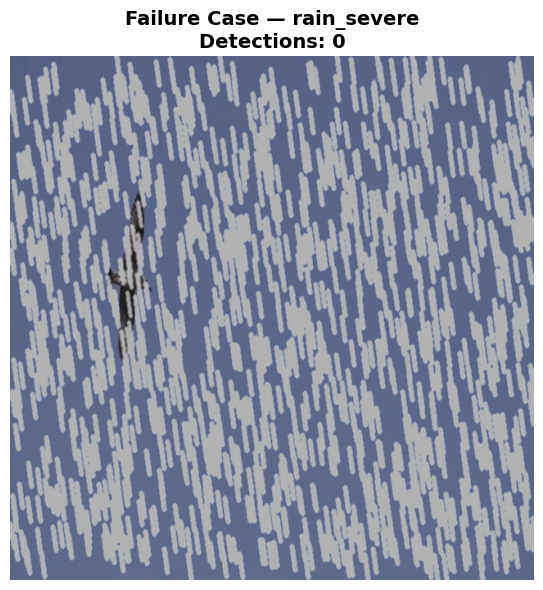

💾 Sauvegardé : /content/drive/MyDrive/AOD4/failure_rain_severe.png


In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random
import cv2
from pathlib import Path
from ultralytics import YOLO

random.seed(42)

# ============================================================
# MODÈLE
# ============================================================

model_robust = YOLO(
    "/content/drive/MyDrive/AOD4/aod4_robust_noise/weights/best.pt"
)

CLASSES = [
    "airplane",
    "bird",
    "drone",
    "helicopter"
]

COLORS = {
    "airplane": "red",
    "bird": "blue",
    "drone": "green",
    "helicopter": "orange"
}


# ============================================================
# TROUVER AUTOMATIQUEMENT LE DOSSIER D'UNE CORRUPTION
# ============================================================

def find_corruption_dir(corruption_name):

    possible_roots = [
        Path("/content/drive/MyDrive/AOD4/corrupted"),
        Path("/content"),
        Path("/content/drive/MyDrive/AOD4")
    ]

    # Chercher directement un dossier portant le nom
    for root in possible_roots:

        if not root.exists():
            continue

        # Recherche récursive
        matches = list(root.rglob(corruption_name))

        for match in matches:

            if match.is_dir() and (match / "images").exists():
                return match

    return None


# ============================================================
# TROUVER UNE VRAIE FAILURE CASE
# ============================================================

def find_failure_image(corrupt_dir, max_checks=100):

    img_dir = Path(corrupt_dir) / "images"

    all_imgs = list(img_dir.glob("*.jpg"))

    if len(all_imgs) == 0:
        return None, None

    # Mélanger les images
    random.shuffle(all_imgs)

    checked = 0

    for img_path in all_imgs:

        if checked >= max_checks:
            break

        checked += 1

        results = model_robust.predict(
            str(img_path),
            conf=0.25,
            verbose=False
        )

        result = results[0]

        # Vraie failure :
        # YOLO ne détecte absolument rien
        if len(result.boxes) == 0:
            return img_path, result

    # Si aucune image avec 0 détection n'a été trouvée
    return None, None


# ============================================================
# AFFICHER UNE FAILURE CASE
# ============================================================

def show_failure_case(corruption_name):

    print("\n" + "=" * 70)
    print(f"Recherche : {corruption_name}")

    # Trouver automatiquement le dossier
    corrupt_dir = find_corruption_dir(corruption_name)

    if corrupt_dir is None:
        print("❌ Dossier de corruption introuvable")
        return

    print(f"📁 Dossier trouvé : {corrupt_dir}")

    img_path, result = find_failure_image(
        corrupt_dir,
        max_checks=100
    )

    if img_path is None:

        print(
            "⚠️ Aucune image avec 0 détection trouvée "
            "parmi les 100 images testées."
        )

        return

    print(f"✅ Failure trouvée : {img_path.name}")

    # ========================================================
    # LIRE IMAGE
    # ========================================================

    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # ========================================================
    # AFFICHAGE
    # ========================================================

    fig, ax = plt.subplots(
        figsize=(8, 6)
    )

    ax.imshow(img_rgb)

    # Dessiner les détections
    for box in result.boxes:

        x1, y1, x2, y2 = (
            box.xyxy[0]
            .cpu()
            .numpy()
        )

        cls_id = int(box.cls[0])
        conf = float(box.conf[0])

        if cls_id < len(CLASSES):
            cls_name = CLASSES[cls_id]
        else:
            cls_name = f"class_{cls_id}"

        color = COLORS.get(
            cls_name,
            "white"
        )

        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor=color,
            facecolor="none"
        )

        ax.add_patch(rect)

        ax.text(
            x1,
            max(y1 - 5, 5),
            f"{cls_name} {conf:.2f}",
            color=color,
            fontsize=9,
            fontweight="bold"
        )

    # Puisqu'on cherche une vraie failure,
    # normalement Detection = 0
    ax.set_title(
        f"Failure Case — {corruption_name}\n"
        f"Detections: {len(result.boxes)}",
        fontsize=14,
        fontweight="bold"
    )

    ax.axis("off")

    plt.tight_layout()

    # ========================================================
    # SAUVEGARDE
    # ========================================================

    save_path = (
        Path("/content/drive/MyDrive/AOD4")
        / f"failure_{corruption_name}.png"
    )

    plt.savefig(
        save_path,
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

    print(f"💾 Sauvegardé : {save_path}")


# ============================================================
# CORRUPTIONS À ANALYSER
# ============================================================

CORRUPTIONS_TO_SHOW = [
    "noise_severe",
    "rain_moderate",
    "rain_severe"
]


# ============================================================
# EXÉCUTION
# ============================================================

for corruption in CORRUPTIONS_TO_SHOW:
    show_failure_case(corruption)